# Question 4 Image Segmentation using GMM

In [1]:
!pip install scikit-image
!pip install imageio[ffmpeg]


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
from skimage.transform import resize
import imageio
import matplotlib.image as mpimg

In [3]:
class GMM:
    def __init__(self, n_components, max_iter=100, tol=1e-4):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.weights = None
        self.means = None
        self.covariances = None
        self.log_likelihoods = []

    def pdf(self, X, mean, cov):
        """
        Calculates the probability density function of a multivariate Gaussian.
        """
        n_features = X.shape[1]
        
        # Add a small epsilon to the diagonal for numerical stability
        epsilon = 1e-6
        cov_reg = cov + np.eye(n_features) * epsilon
        
        det_cov = np.linalg.det(cov_reg)
        
        # Check for non-positive determinant
        if det_cov <= 0:
            return np.zeros(X.shape[0])
            
        inv_cov = np.linalg.inv(cov_reg)
        coeff = 1 / np.sqrt((2 * np.pi) ** n_features * det_cov)
        diff = X - mean
        exponent = -0.5 * np.sum((diff @ inv_cov) * diff, axis=1)
        
        return coeff * np.exp(exponent)

    def initialize_parameters(self, data):
        """Initializes the GMM parameters (means, covariances, weights)."""
        n_samples, n_features = data.shape
        
        # 1. Randomly select data points as initial means
        random_indices = np.random.choice(n_samples, self.n_components, replace=False)
        self.means = data[random_indices]

        # 2. Initialize covariances as identity matrices
        self.covariances = [np.eye(n_features) for _ in range(self.n_components)]

        # 3. Initialize weights uniformly
        self.weights = np.ones(self.n_components) / self.n_components
        
        # Clear log likelihoods from previous fits
        self.log_likelihoods = []

    def _e_step(self, data):
        """
        Performs the E-step of the EM algorithm.
        Calculates the responsibilities and the log-likelihood.
        """
        n_samples = data.shape[0]
        responsibilities = np.zeros((n_samples, self.n_components))

        for k in range(self.n_components):
            # Calculate the likelihood of each data point for component k
            likelihood = self.pdf(data, self.means[k], self.covariances[k])
            responsibilities[:, k] = self.weights[k] * likelihood
        
        # Calculate the sum of responsibilities for normalization and log-likelihood
        responsibilities_sum = responsibilities.sum(axis=1, keepdims=True) + 1e-8
        
        # Calculate the log-likelihood for the current iteration
        log_likelihood = np.sum(np.log(responsibilities_sum))
        
        # Normalize the responsibilities
        responsibilities /= responsibilities_sum
        
        return responsibilities, log_likelihood

    def _m_step(self, data, responsibilities):
        """
        Performs the M-step of the EM algorithm.
        Updates the parameters (means, covariances, weights).
        """
        n_samples, n_features = data.shape
        
        # Sum of responsibilities for each component
        N_k = responsibilities.sum(axis=0)
        
        # 1. Update weights
        self.weights = N_k / n_samples
        
        # 2. Update means
        self.means = (responsibilities.T @ data) / N_k[:, np.newaxis]
        
        # 3. Update covariances
        regularization = 1e-6 * np.eye(n_features) # For numerical stability
        for k in range(self.n_components):
            diff = data - self.means[k]
            # Vectorized way to compute sum of weighted outer products
            weighted_sum = (responsibilities[:, k][:, np.newaxis] * diff).T @ diff
            self.covariances[k] = weighted_sum / N_k[k] + regularization

    def fit(self, data):
        """
        Fits the GMM to the data by running the full EM algorithm.
        """
        # 1. Initialize parameters
        self.initialize_parameters(data)
        
        # Initialize log-likelihood for convergence check
        log_likelihood = -np.inf 

        for iteration in range(self.max_iter):
            # 2. Perform E-Step
            responsibilities, new_log_likelihood = self._e_step(data)
            
            # 3. Perform M-Step
            self._m_step(data, responsibilities)
            
            # 4. Store log-likelihood for plotting
            self.log_likelihoods.append(new_log_likelihood)
            
            # 5. Check for convergence
            if abs(new_log_likelihood - log_likelihood) < self.tol:
                print(f"Converged at iteration {iteration+1}")
                break
            
            log_likelihood = new_log_likelihood

        print("Fitting complete.")
    
    def getMembership(self, data):
        """
        Returns the membership values (probabilities) for each sample.
        """
        if self.means is None:
            raise RuntimeError("You must fit the model before getting memberships.")
        
        responsibilities = np.zeros((data.shape[0], self.n_components))
        for k in range(self.n_components):
            pdf_vals = self.pdf(data, self.means[k], self.covariances[k])
            responsibilities[:, k] = self.weights[k] * pdf_vals
            
        responsibilites_sum = responsibilities.sum(axis=1, keepdims=True)
        # Normalize to get probabilities
        memberships = responsibilities / (responsibilites_sum + 1e-9)
        return memberships

    def getLikelihood(self, data):
        """
        Returns the overall log-likelihood of the dataset under the current model.
        """
        if self.means is None:
            raise RuntimeError("You must fit the model before getting the likelihood.")
        
        responsibilities = np.zeros((data.shape[0], self.n_components))
        for k in range(self.n_components):
            pdf_vals = self.pdf(data, self.means[k], self.covariances[k])
            responsibilities[:, k] = self.weights[k] * pdf_vals
            
        # The likelihood for each point is the sum of weighted PDFs
        likelihood_per_sample = responsibilities.sum(axis=1)
        
        # The total log-likelihood is the sum of the logs of these likelihoods
        total_log_likelihood = np.sum(np.log(likelihood_per_sample + 1e-9))
        return total_log_likelihood

    def drawLikelihood(self):
        """
        Draws the plot of log-likelihood vs. iterations.
        """
        if not self.log_likelihoods:
            raise RuntimeError("You must fit the model before drawing the likelihood plot.")
            
        plt.figure(figsize=(8, 6))
        plt.plot(range(1, len(self.log_likelihoods) + 1), self.log_likelihoods, marker='o', linestyle='-')
        plt.title('Log-Likelihood vs. Iterations')
        plt.xlabel('Iteration')
        plt.ylabel('Log-Likelihood')
        plt.grid(True)
        plt.show()
    

    def predict(self, data):
        """Predict the cluster for each data point based on highest membership."""
        memberships = self.getMembership(data)
        return np.argmax(memberships, axis=1)



In [4]:
img1 = mpimg.imread('./Dataset/Q4/satellite_1.png')
img2 = mpimg.imread('./Dataset/Q4/satellite_2.png')

def preprocess_image(img):
    """ Preprocess the image to ensure it's in uint8 format. """
    if img.dtype == np.float32 or img.dtype == np.float64:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)
    return img


img1 = preprocess_image(img1)
img2 = preprocess_image(img2)

print(img1.shape, img2.shape)
print(img1.dtype, img2.dtype)

# Reshape the images to be a list of pixels
img1_reshaped = img1.reshape(-1, img1.shape[-1])
img2_reshaped = img2.reshape(-1, img2.shape[-1])

# # standardizing the data
scaler = StandardScaler()
img1_reshaped = scaler.fit_transform(img1_reshaped)
img2_reshaped = scaler.fit_transform(img2_reshaped)

print("Shape of reshaped image 1:", img1_reshaped.shape)

(767, 1000, 3) (1600, 755, 3)
uint8 uint8
Shape of reshaped image 1: (767000, 3)


In [5]:
gmm = GMM(n_components=3, max_iter=100, tol=1e-4)

gmm.fit(img1_reshaped)
labels_img1 = gmm.predict(img1_reshaped)
segmented_img1 = labels_img1.reshape(img1.shape[0], img1.shape[1])

gmm.fit(img2_reshaped)
labels_img2 = gmm.predict(img2_reshaped)
segmented_img2 = labels_img2.reshape(img2.shape[0], img2.shape[1])

Converged at iteration 82
Fitting complete.
Fitting complete.


(-0.5, 754.5, 1599.5, -0.5)

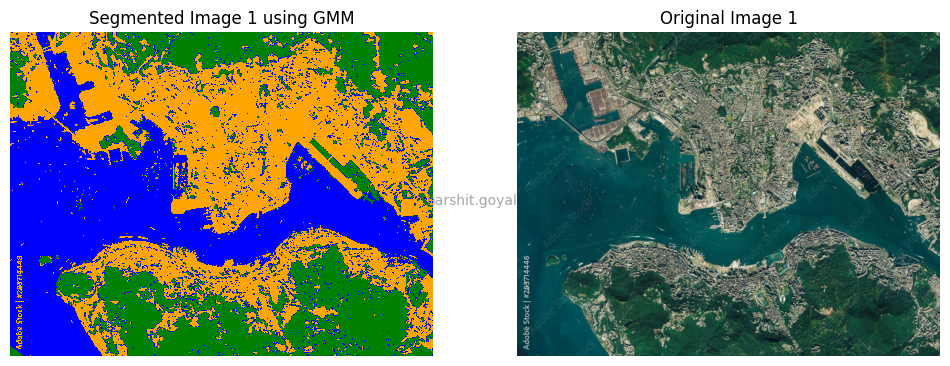

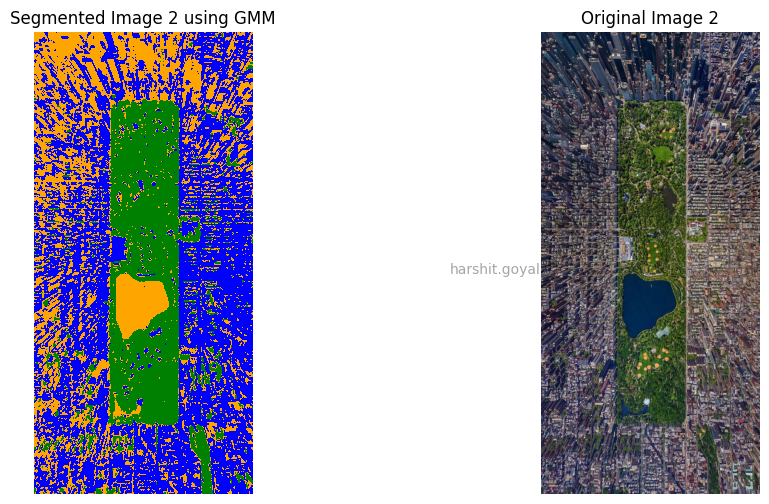

In [6]:
custom_cmap1 = ListedColormap(['orange', 'blue', 'green'])
custom_cmap2 = ListedColormap(['green', 'orange', 'blue'])
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(segmented_img1, cmap=custom_cmap1)
plt.title('Segmented Image 1 using GMM')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img1)
plt.title('Original Image 1')
plt.axis('off')
plt.text(0, 0.5, "harshit.goyal",ha='right', va='top',transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(segmented_img2, cmap=custom_cmap2)
plt.title('Segmented Image 2 using GMM')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.title('Original Image 2')
plt.text(0, 0.5, "harshit.goyal",ha='right', va='top',transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)
plt.axis('off')


In [ ]:
def video_generation(img, img_reshaped, FILENAME='gmm_fitting_video.mp4'):
    """ Generates a video showing the GMM fitting process. """
    frames = []
    logLikelihood =[]

    def create_plot_panel(log_likelihoods):
        """Generates an image of the log-likelihood plot."""
        fig, ax = plt.subplots(figsize=(6, 4.5), dpi=100)
        
        iterations = range(1, len(log_likelihoods) + 1)
        ax.plot(iterations, log_likelihoods, marker='o', linestyle='--')
        
        ax.set_title("Log-Likelihood vs. Iteration")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Log-Likelihood")
        ax.grid(True)
        ax.text(0.95, 0.95, "harshit.goyal",ha='right', va='top',transform=ax.transAxes,fontsize=10, color='gray', alpha=0.7)
        fig.tight_layout()
        fig.canvas.draw()
        
        rgba_buffer = fig.canvas.buffer_rgba()
        plot_img_rgba = np.asarray(rgba_buffer)
        plot_img = plot_img_rgba[:, :, :3] 
        plt.close(fig)
        return plot_img

    for i in range(gmm.max_iter):
        responsibility , log =gmm._e_step(img_reshaped)
        gmm._m_step(img_reshaped,responsibility)
        logLikelihood.append(log)
        
        panel1= img
        height = panel1.shape[0]
        width = panel1.shape[1]

        colors = responsibility @ np.array([[0, 0, 1], [1, 0, 0], [0, 1, 0]])
        panel2 = (colors.reshape(height, width, 3) * 255).astype(np.uint8)
        panel3 = create_plot_panel(logLikelihood)

        panel2_resized = resize(panel2, (height, width),preserve_range=True).astype(np.uint8)
        panel3_resized = resize(panel3, (height, width),preserve_range=True).astype(np.uint8)
        combined_frame = np.hstack((panel1, panel2_resized, panel3_resized)).astype(np.uint8)

        # Add the final combined frame to your list for the video
        frames.append(combined_frame)

    imageio.mimsave(FILENAME, frames, fps=3,)

video_generation(img1, img1_reshaped, FILENAME='ques4_img1.mp4')
video_generation(img2, img2_reshaped, FILENAME='ques4_img2.mp4')

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 767) to (3008, 768) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (2265, 1600) to (2272, 1600) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


## Video link:
https://iiithydstudents-my.sharepoint.com/:f:/g/personal/harshit_goyal_students_iiit_ac_in/EnFprNK-8DZKioeTR9573agBCfeoQsuudgbKOhsugTvGVQ?e=fJk261